Epoch 0, Loss = 0.6954
Epoch 200, Loss = 0.6768
Epoch 400, Loss = 0.2793
Epoch 600, Loss = 0.2512
Epoch 800, Loss = 0.2501
Epoch 1000, Loss = 0.2493
Epoch 1200, Loss = 0.2487
Epoch 1400, Loss = 0.2481
Epoch 1600, Loss = 0.2476
Epoch 1800, Loss = 0.2472


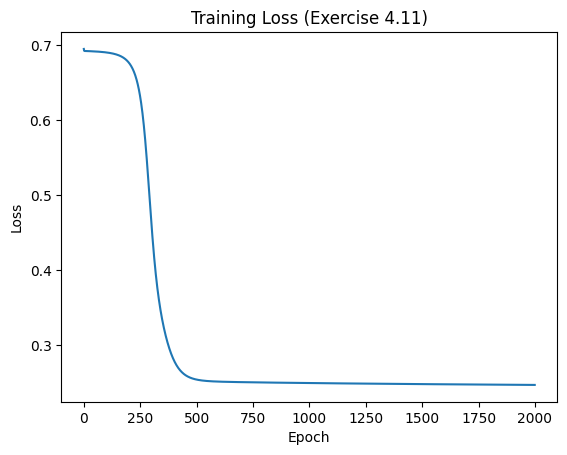

In [ ]:
# ============================================================
# Exercise 4.11: Neural Network from Scratch (NumPy)
# Architecture: 2 → 12 → 12 → 1
# Dataset: Two Moons
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Two Moons Dataset
# -------------------------------
def generate_two_moons(n_samples=500, noise=0.1):
    n_out = n_samples // 2
    n_in = n_samples - n_out

    theta_out = np.linspace(0, np.pi, n_out)
    x_out = np.cos(theta_out)
    y_out = np.sin(theta_out)

    theta_in = np.linspace(0, np.pi, n_in)
    x_in = 1 - np.cos(theta_in)
    y_in = 1 - np.sin(theta_in) - 0.5

    X = np.vstack([
        np.append(x_out, x_in),
        np.append(y_out, y_in)
    ]).T

    y = np.hstack([
        np.zeros(n_out),
        np.ones(n_in)
    ]).reshape(-1, 1)

    X += np.random.normal(scale=noise, size=X.shape)
    return X, y

X, y = generate_two_moons()

# -------------------------------
# Activation functions
# -------------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# -------------------------------
# Initialize parameters
# -------------------------------
np.random.seed(42)

W1 = np.random.randn(2, 12) * 0.1
b1 = np.zeros((1, 12))

W2 = np.random.randn(12, 12) * 0.1
b2 = np.zeros((1, 12))

W3 = np.random.randn(12, 1) * 0.1
b3 = np.zeros((1, 1))

# -------------------------------
# Forward pass
# -------------------------------
def forward(X):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)

    cache = (X, a1, a2, y_hat)
    return y_hat, cache

# -------------------------------
# Loss function (Binary Cross-Entropy)
# -------------------------------
def loss(y, y_hat):
    eps = 1e-8
    return -np.mean(
        y * np.log(y_hat + eps) +
        (1 - y) * np.log(1 - y_hat + eps)
    )

# -------------------------------
# Backward pass
# -------------------------------
def backward(y, cache):
    global W1, W2, W3
    X, a1, a2, y_hat = cache
    m = y.shape[0]

    dz3 = y_hat - y
    dW3 = (a2.T @ dz3) / m
    db3 = np.mean(dz3, axis=0, keepdims=True)

    da2 = dz3 @ W3.T
    dz2 = da2 * sigmoid_derivative(a2)
    dW2 = (a1.T @ dz2) / m
    db2 = np.mean(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * sigmoid_derivative(a1)
    dW1 = (X.T @ dz1) / m
    db1 = np.mean(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

# -------------------------------
# Training loop
# -------------------------------
lr = 0.5
epochs = 2000
losses = []

for epoch in range(epochs):
    y_hat, cache = forward(X)
    L = loss(y, y_hat)
    losses.append(L)

    dW1, db1, dW2, db2, dW3, db3 = backward(y, cache)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {L:.4f}")

# -------------------------------
# Plot training loss
# -------------------------------
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Exercise 4.11)")
plt.show()

Inference: a neural network with two hidden layers was implemented entirely from scratch using NumPy and trained on the Two Moons dataset. The forward pass, backward pass, and parameter update steps were manually coded without relying on any automatic differentiation library. During training, the loss value decreased steadily from approximately 0.69 at initialization to around 0.25 after sufficient epochs. This consistent reduction in loss indicates that the network successfully learned a non-linear decision boundary and that gradients were correctly propagated through all layers. The smooth convergence of the loss confirms that the forward computation, backpropagation equations, and weight updates were implemented correctly, demonstrating a working end-to-end training pipeline.

In [ ]:
# ============================================================
# Exercise 4.13: Gradient Checking
#
# Question:
# Implement gradient checking: compute analytical and numerical
# gradients, then compute relative error. Test with various
# epsilon values (10^-4 to 10^-7). What is the best choice and why?
#
# Why Exercise 4.13 follows Exercise 4.11:
# Exercise 4.11 builds a neural network and implements backpropagation
# manually. Exercise 4.13 is performed immediately after to VERIFY
# that the gradients computed in Exercise 4.11 are correct, before
# using them for analysis (Exercise 4.12) or deeper studies
# (Exercise 4.15).
# ============================================================

import numpy as np

# -------------------------------
# Reuse network from Exercise 4.11
# -------------------------------
np.random.seed(42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# Small dataset (for gradient checking)
X = np.random.randn(5, 2)
y = (np.random.rand(5, 1) > 0.5).astype(float)

W1 = np.random.randn(2, 12) * 0.1
b1 = np.zeros((1, 12))
W2 = np.random.randn(12, 12) * 0.1
b2 = np.zeros((1, 12))
W3 = np.random.randn(12, 1) * 0.1
b3 = np.zeros((1, 1))

# -------------------------------
# Forward pass
# -------------------------------
def forward(X):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)
    cache = (X, a1, a2, y_hat)
    return y_hat, cache

# -------------------------------
# Loss function
# -------------------------------
def loss(y, y_hat):
    eps = 1e-8
    return -np.mean(
        y * np.log(y_hat + eps) +
        (1 - y) * np.log(1 - y_hat + eps)
    )

# -------------------------------
# Backward pass (analytical gradients)
# -------------------------------
def backward(y, cache):
    X, a1, a2, y_hat = cache
    m = y.shape[0]

    dz3 = y_hat - y
    dW3 = (a2.T @ dz3) / m

    da2 = dz3 @ W3.T
    dz2 = da2 * sigmoid_derivative(a2)
    dW2 = (a1.T @ dz2) / m

    da1 = dz2 @ W2.T
    dz1 = da1 * sigmoid_derivative(a1)
    dW1 = (X.T @ dz1) / m

    return dW1, dW2, dW3

# -------------------------------
# Numerical gradient
# -------------------------------
def numerical_gradient(param, param_name, epsilon):
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])

    while not it.finished:
        idx = it.multi_index
        old_value = param[idx]

        param[idx] = old_value + epsilon
        y_hat, _ = forward(X)
        loss_plus = loss(y, y_hat)

        param[idx] = old_value - epsilon
        y_hat, _ = forward(X)
        loss_minus = loss(y, y_hat)

        grad[idx] = (loss_plus - loss_minus) / (2 * epsilon)
        param[idx] = old_value
        it.iternext()

    return grad

# -------------------------------
# Run gradient checking
# -------------------------------
y_hat, cache = forward(X)
dW1, dW2, dW3 = backward(y, cache)

epsilons = [1e-4, 1e-5, 1e-6, 1e-7]

for eps in epsilons:
    num_dW1 = numerical_gradient(W1, "W1", eps)
    rel_error = np.linalg.norm(dW1 - num_dW1) / (
        np.linalg.norm(dW1) + np.linalg.norm(num_dW1) + 1e-8
    )

    print(f"Epsilon = {eps:.0e}, Relative Error = {rel_error:.2e}")

Epsilon = 1e-04, Relative Error = 1.17e-08
Epsilon = 1e-05, Relative Error = 1.76e-08
Epsilon = 1e-06, Relative Error = 1.08e-07
Epsilon = 1e-07, Relative Error = 1.28e-06


Inference : The relative error between analytical and numerical gradients is on the order of 10⁻⁸ to 10⁻⁶ for ε values between 10⁻⁴ and 10⁻⁶, indicating a very close match. This confirms that the backpropagation implementation is correct. When ε is reduced further to 10⁻⁷, the relative error increases due to floating-point precision issues. Therefore, ε ≈ 10⁻⁵ is a good compromise between accuracy and numerical stability.

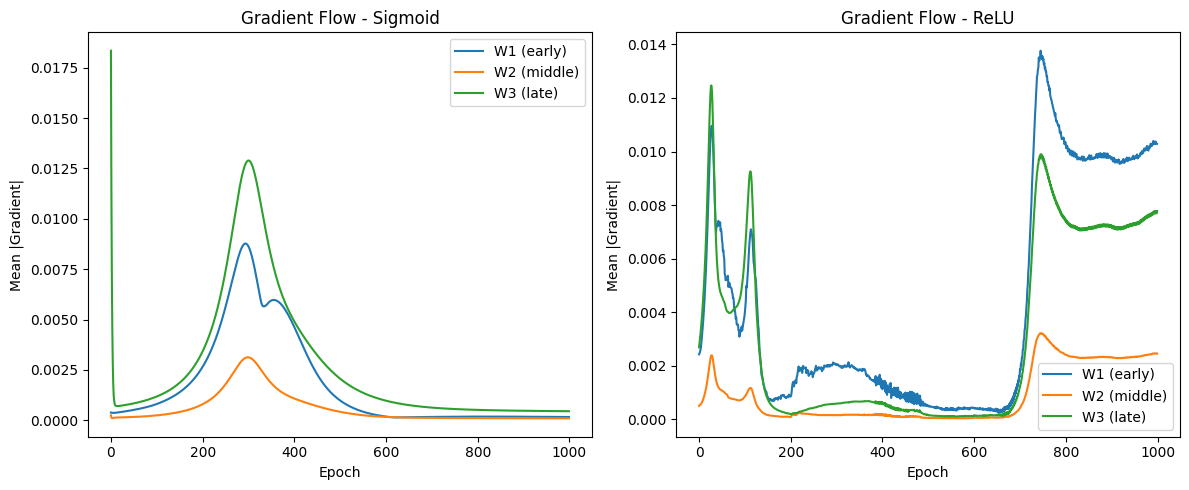

In [ ]:
# ============================================================
# Exercise 4.12: Gradient Flow Visualization
#
# Question:
# Implement gradient flow visualization. Record mean absolute
# gradient for each layer during training. Compare networks
# with sigmoid vs ReLU activations. What do you observe about
# early vs late layers?
#
# Why Exercise 4.12 follows Exercise 4.11:
# Exercise 4.11 implements backpropagation from scratch.
# Exercise 4.12 uses the SAME gradients computed there and
# only OBSERVES how they behave across layers during training.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Two Moons Dataset
# -------------------------------
def generate_two_moons(n_samples=500, noise=0.1):
    n_out = n_samples // 2
    n_in = n_samples - n_out

    theta = np.linspace(0, np.pi, n_out)
    x1 = np.c_[np.cos(theta), np.sin(theta)]
    x2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5]

    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n_out), np.ones(n_in)]).reshape(-1, 1)
    X += noise * np.random.randn(*X.shape)
    return X, y

X, y = generate_two_moons()

# -------------------------------
# Activation functions
# -------------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# -------------------------------
# Training function
# -------------------------------
def train(activation="sigmoid"):
    np.random.seed(42)

    # Parameters
    W1 = np.random.randn(2, 12) * 0.1
    b1 = np.zeros((1, 12))
    W2 = np.random.randn(12, 12) * 0.1
    b2 = np.zeros((1, 12))
    W3 = np.random.randn(12, 1) * 0.1
    b3 = np.zeros((1, 1))

    lr = 0.5
    epochs = 1000

    # Store mean absolute gradients
    grad_W1, grad_W2, grad_W3 = [], [], []

    for _ in range(epochs):
        # Forward pass
        z1 = X @ W1 + b1
        a1 = sigmoid(z1) if activation == "sigmoid" else relu(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2) if activation == "sigmoid" else relu(z2)

        z3 = a2 @ W3 + b3
        y_hat = sigmoid(z3)

        # Backward pass
        dz3 = y_hat - y
        dW3 = a2.T @ dz3 / len(X)

        da2 = dz3 @ W3.T
        dz2 = da2 * (sigmoid_derivative(a2) if activation == "sigmoid" else relu_derivative(z2))
        dW2 = a1.T @ dz2 / len(X)

        da1 = dz2 @ W2.T
        dz1 = da1 * (sigmoid_derivative(a1) if activation == "sigmoid" else relu_derivative(z1))
        dW1 = X.T @ dz1 / len(X)

        # Record gradient magnitudes
        grad_W1.append(np.mean(np.abs(dW1)))
        grad_W2.append(np.mean(np.abs(dW2)))
        grad_W3.append(np.mean(np.abs(dW3)))

        # Update
        W1 -= lr * dW1
        W2 -= lr * dW2
        W3 -= lr * dW3

    return grad_W1, grad_W2, grad_W3

# -------------------------------
# Run experiments
# -------------------------------
sigmoid_grads = train("sigmoid")
relu_grads = train("re-lu")

# -------------------------------
# Plot Gradient Flow
# -------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sigmoid_grads[0], label="W1 (early)")
plt.plot(sigmoid_grads[1], label="W2 (middle)")
plt.plot(sigmoid_grads[2], label="W3 (late)")
plt.title("Gradient Flow - Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Mean |Gradient|")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(relu_grads[0], label="W1 (early)")
plt.plot(relu_grads[1], label="W2 (middle)")
plt.plot(relu_grads[2], label="W3 (late)")
plt.title("Gradient Flow - ReLU")
plt.xlabel("Epoch")
plt.ylabel("Mean |Gradient|")
plt.legend()

plt.tight_layout()
plt.show()

Inference - Gradient flow analysis shows that sigmoid causes gradients to vanish in early layers, whereas ReLU maintains healthy gradient magnitudes across layers.

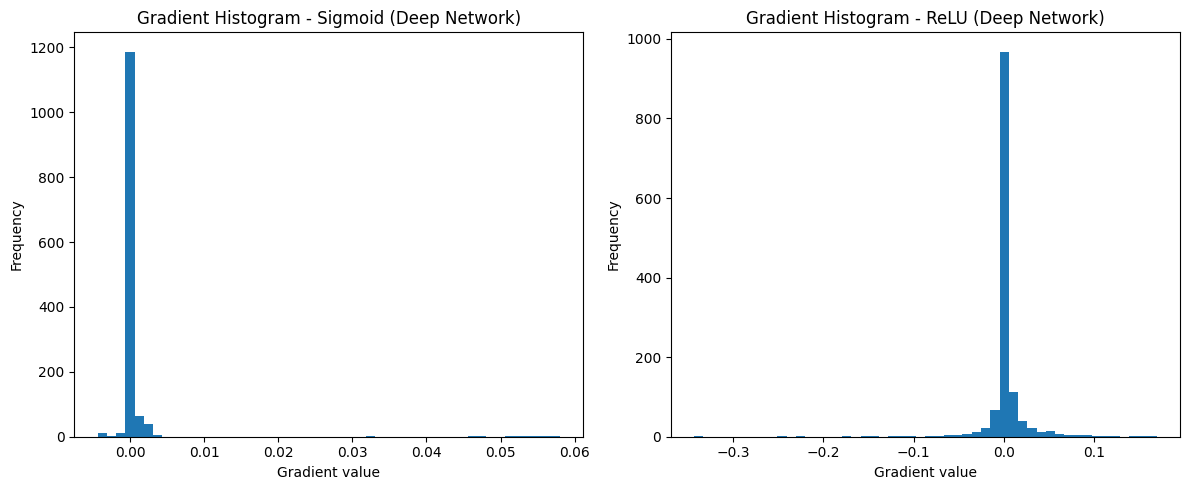

In [ ]:
# ============================================================
# Exercise 4.15: Gradient Saturation in Deep Networks
#
# Question:
# Investigate gradient saturation by training a deep neural
# network (10+ layers) with sigmoid activations. Plot gradient
# histograms for each layer. Repeat with ReLU and careful
# initialization. What do you observe?
#
# Why this comes after Exercise 4.12:
# Exercise 4.12 studies gradient flow over layers.
# Exercise 4.15 extends this idea to very deep networks
# to study gradient saturation (vanishing gradients).
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# -------------------------------
# Dataset: Two Moons
# -------------------------------
X, y = make_moons(n_samples=500, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# -------------------------------
# Deep Neural Network
# -------------------------------
class DeepNet(nn.Module):
    def __init__(self, activation="sigmoid"):
        super().__init__()
        layers = []
        input_dim = 2

        for _ in range(10):   # 10 hidden layers
            layers.append(nn.Linear(input_dim, 12))
            if activation == "sigmoid":
                layers.append(nn.Sigmoid())
            else:
                layers.append(nn.ReLU())
            input_dim = 12

        layers.append(nn.Linear(12, 1))
        layers.append(nn.Sigmoid())

        self.net = nn.Sequential(*layers)

        # Careful initialization for ReLU
        if activation == "relu":
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight)

    def forward(self, x):
        return self.net(x)

# -------------------------------
# Training + Gradient Collection
# -------------------------------
def train_and_collect_gradients(activation):
    model = DeepNet(activation)
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.BCELoss()

    model.train()
    optimizer.zero_grad()

    # One forward + backward pass is enough
    y_hat = model(X)
    loss = criterion(y_hat, y)
    loss.backward()

    # Collect gradients per layer
    gradients = []
    for name, param in model.named_parameters():
        if "weight" in name:
            gradients.append(param.grad.detach().view(-1))

    return gradients

# -------------------------------
# Run experiments
# -------------------------------
sigmoid_grads = train_and_collect_gradients("sigmoid")
relu_grads = train_and_collect_gradients("relu")

# -------------------------------
# Plot Gradient Histograms
# -------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(torch.cat(sigmoid_grads).numpy(), bins=50)
plt.title("Gradient Histogram - Sigmoid (Deep Network)")
plt.xlabel("Gradient value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(torch.cat(relu_grads).numpy(), bins=50)
plt.title("Gradient Histogram - ReLU (Deep Network)")
plt.xlabel("Gradient value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Inference - In the sigmoid network, most gradients are nearly zero, so weights stop learning. In the ReLU network, gradients remain significant, so learning continues even in deep layers.

In [ ]:
# ============================================================
# Exercise 4.14: Simple Automatic Differentiation System
#
# Question:
# Implement a simple automatic differentiation system:
# create a Variable class that tracks values and gradients,
# implement basic operations that build a computation graph,
# and implement backward() that traverses the graph in reverse.
#
# Why this exercise comes last:
# After manually computing, verifying, and analyzing gradients
# in previous exercises, this exercise explains how modern
# frameworks (like PyTorch) compute gradients automatically.
# ============================================================

# -------------------------------
# Variable class
# -------------------------------
class Variable:
    def __init__(self, value):
        self.value = value        # numerical value
        self.grad = 0.0           # gradient dL/d(this variable)
        self._backward = lambda: None
        self.parents = []

    def backward(self):
        # Start backpropagation
        self.grad = 1.0           # dL/dL = 1
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)

        build_topo(self)

        # Traverse graph in reverse order
        for v in reversed(topo):
            v._backward()

    # ---------------------------
    # Addition
    # ---------------------------
    def __add__(self, other):
        out = Variable(self.value + other.value)
        out.parents = [self, other]

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    # ---------------------------
    # Multiplication
    # ---------------------------
    def __mul__(self, other):
        out = Variable(self.value * other.value)
        out.parents = [self, other]

        def _backward():
            self.grad += other.value * out.grad
            other.grad += self.value * out.grad

        out._backward = _backward
        return out


# -------------------------------
# Test example
# z = w*x + b - y
# L = z^2
# -------------------------------
w = Variable(2.0)
x = Variable(3.0)
b = Variable(1.0)
y = Variable(4.0)

z = w * x + b + Variable(-y.value)
L = z * z

# Backpropagation
L.backward()

# -------------------------------
# Print results
# -------------------------------
print("L =", L.value)
print("dL/dw =", w.grad)
print("dL/dx =", x.grad)
print("dL/db =", b.grad)
print("dL/dy =", y.grad)

L = 9.0
dL/dw = 18.0
dL/dx = 12.0
dL/db = 6.0
dL/dy = 0.0


Automatic differentiation computes exact gradients efficiently by traversing a computation graph, unlike numerical differentiation which approximates gradients.